# Baseline Regression Model for Bike-Sharing Demand

After performing exploratory data analysis, the next step is to build a baseline predictive model.

A baseline model serves as a simple starting point that helps establish:

- A reference level of performance
- Initial understanding of feature relationships
- A foundation for further model improvements

In this stage, we:

- Split the dataset into training and testing sets
- Build a linear regression model using weather-related variables
- Evaluate model performance using standard metrics

This aligns with the first modeling task outlined in the regression module.

## Import Required Libraries

We use:

- `dplyr`: data manipulation
- `ggplot2`: visualization
- `caret`: model training and evaluation

In [1]:
# -------------------------------
# Install and Load Required Libraries
# -------------------------------

# Create a vector of required packages
required_packages <- c(
  "dplyr",
  "ggplot2",
  "readr",
  "tidyr",
  "stringr",
  "caret",
  "glmnet",
  "broom",
  "car",
  "httr",
  "jsonlite",
  "leaflet",
  "tidyverse",
  "scales"
)

# Install missing packages only
installed_packages <- rownames(installed.packages())

for (pkg in required_packages) {
  if (!(pkg %in% installed_packages)) {
    install.packages(pkg)
  }
}

# Load all libraries
lapply(required_packages, library, character.only = TRUE)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Loading required package: lattice

Loading required package: Matrix


Attaching package: 'Matrix'


The following objects are masked from 'package:tidyr':

    expand, pack, unpack


Loaded glmnet 4.1-10

Loading required package: carData


Attaching package: 'car'


The following object is masked from 'package:dplyr':

    recode



Attaching package: 'httr'


The following object is masked from 'package:caret':

    progress


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ purrr     1.0.4
✔ lubridate 1.9.4     ✔ tibble    3.2.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ Matrix::expand() masks tidyr::expand()
✖ dplyr::filter()  masks stats::filter()
✖ purrr::flatten() masks jsonlite::flatten

[[1]]
[1] "dplyr"     "stats"     "graphics"  "grDevices" "utils"     "datasets" 
[7] "methods"   "base"     

[[2]]
[1] "ggplot2"   "dplyr"     "stats"     "graphics"  "grDevices" "utils"    
[7] "datasets"  "methods"   "base"     

[[3]]
 [1] "readr"     "ggplot2"   "dplyr"     "stats"     "graphics"  "grDevices"
 [7] "utils"     "datasets"  "methods"   "base"     

[[4]]
 [1] "tidyr"     "readr"     "ggplot2"   "dplyr"     "stats"     "graphics" 
 [7] "grDevices" "utils"     "datasets"  "methods"   "base"     

[[5]]
 [1] "stringr"   "tidyr"     "readr"     "ggplot2"   "dplyr"     "stats"    
 [7] "graphics"  "grDevices" "utils"     "datasets"  "methods"   "base"     

[[6]]
 [1] "caret"     "lattice"   "stringr"   "tidyr"     "readr"     "ggplot2"  
 [7] "dplyr"     "stats"     "graphics"  "grDevices" "utils"     "datasets" 
[13] "methods"   "base"     

[[7]]
 [1] "glmnet"    "Matrix"    "caret"     "lattice"   "stringr"   "tidyr"    
 [7] "readr"     "ggplot2"   "dplyr"     "stats"     "graphics"  "grDevices"
[13] "utils"     "datasets"  "methods"   "base"     

[[8]]
 [1] "broom"     "glmnet"    "Matrix"    "caret"     "lattice"   "stringr"  
 [7] "tidyr"     "readr"     "ggplot2"   "dplyr"     "stats"     "graphics" 
[13] "grDevices" "utils"     "datasets"  "methods"   "base"     

[[9]]
 [1] "car"       "carData"   "broom"     "glmnet"    "Matrix"    "caret"    
 [7] "lattice"   "stringr"   "tidyr"     "readr"     "ggplot2"   "dplyr"    
[13] "stats"     "graphics"  "grDevices" "utils"     "datasets"  "methods"  
[19] "base"     

[[10]]
 [1] "httr"      "car"       "carData"   "broom"     "glmnet"    "Matrix"   
 [7] "caret"     "lattice"   "stringr"   "tidyr"     "readr"     "ggplot2"  
[13] "dplyr"     "stats"     "graphics"  "grDevices" "utils"     "datasets" 
[19] "methods"   "base"     

[[11]]
 [1] "jsonlite"  "httr"      "car"       "carData"   "broom"     "glmnet"   
 [7] "Matrix"    "caret"     "lattice"   "stringr"   "tidyr"     "readr"    
[13] "ggplot2"   "dplyr"     "stats"     "graphics"  "grDevices" "utils"    
[19] "datasets"  "methods"   "base"     

[[12]]
 [1] "leaflet"   "jsonlite"  "httr"      "car"       "carData"   "broom"    
 [7] "glmnet"    "Matrix"    "caret"     "lattice"   "stringr"   "tidyr"    
[13] "readr"     "ggplot2"   "dplyr"     "stats"     "graphics"  "grDevices"
[19] "utils"     "datasets"  "methods"   "base"     

[[13]]
 [1] "lubridate" "forcats"   "purrr"     "tibble"    "tidyverse" "leaflet"  
 [7] "jsonlite"  "httr"      "car"       "carData"   "broom"     "glmnet"   
[13] "Matrix"    "caret"     "lattice"   "stringr"   "tidyr"     "readr"    
[19] "ggplot2"   "dplyr"     "stats"     "graphics"  "grDevices" "utils"    
[25] "datasets"  "methods"   "base"     

[[14]]
 [1] "scales"    "lubridate" "forcats"   "purrr"     "tibble"    "tidyverse"
 [7] "leaflet"   "jsonlite"  "httr"      "car"       "carData"   "broom"    
[13] "glmnet"    "Matrix"    "caret"     "lattice"   "stringr"   "tidyr"    
[19] "readr"     "ggplot2"   "dplyr"     "stats"     "graphics"  "grDevices"
[25] "utils"     "datasets"  "methods"   "base"

## Load Prepared Dataset

We load the cleaned dataset generated from the ETL stage.

In [2]:
# Load cleaned dataset
bike_data <- read_csv("clean_bike_data.csv")

# Display first few rows
head(bike_data)

Rows: 8465 Columns: 17
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr   (4): seasons, holiday, functioning_day, day_of_week
dbl  (12): rented_bike_count, hour, temperature, humidity, wind_speed, visib...
date  (1): date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


date,rented_bike_count,hour,temperature,humidity,wind_speed,visibility,dew_point_temperature,solar_radiation,rainfall,snowfall,seasons,holiday,functioning_day,year,month,day_of_week
<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
2017-12-01,254,0,-5.2,37,2.2,2000,-17.6,0,0,0,Winter,No Holiday,Yes,2017,12,Friday
2017-12-01,204,1,-5.5,38,0.8,2000,-17.6,0,0,0,Winter,No Holiday,Yes,2017,12,Friday
2017-12-01,173,2,-6.0,39,1.0,2000,-17.7,0,0,0,Winter,No Holiday,Yes,2017,12,Friday
2017-12-01,107,3,-6.2,40,0.9,2000,-17.6,0,0,0,Winter,No Holiday,Yes,2017,12,Friday
2017-12-01,78,4,-6.0,36,2.3,2000,-18.6,0,0,0,Winter,No Holiday,Yes,2017,12,Friday
2017-12-01,100,5,-6.4,37,1.5,2000,-18.7,0,0,0,Winter,No Holiday,Yes,2017,12,Friday


## Split Data into Training and Testing Sets

To evaluate model performance fairly, we split the dataset:

- Training set: used to train the model
- Testing set: used to evaluate model performance

In [3]:
# Set seed for reproducibility
set.seed(123)

# Create data partition (80% train, 20% test)
train_index <- createDataPartition(bike_data$rented_bike_count, p = 0.8, list = FALSE)

# Split dataset
train_data <- bike_data[train_index, ]
test_data <- bike_data[-train_index, ]

## Build Baseline Linear Regression Model

We build a simple linear regression model using only weather-related variables:

- Temperature
- Humidity
- Wind speed

This model serves as a benchmark for future improvements.

In [4]:
# Train baseline linear regression model

baseline_model <- lm(
  rented_bike_count ~ temperature + humidity + wind_speed,
  data = train_data
)

# Display model summary
summary(baseline_model)


Call:
lm(formula = rented_bike_count ~ temperature + humidity + wind_speed, 
    data = train_data)

Residuals:
     Min       1Q   Median       3Q      Max 
-1268.90  -306.03   -71.68   183.66  2406.85 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) 771.2271    24.8381  31.050  < 2e-16 ***
temperature  32.5176     0.5023  64.739  < 2e-16 ***
humidity     -8.8374     0.3155 -28.010  < 2e-16 ***
wind_speed   33.7861     6.1696   5.476  4.5e-08 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 494.5 on 6770 degrees of freedom
Multiple R-squared:  0.4083,	Adjusted R-squared:  0.4081 
F-statistic:  1557 on 3 and 6770 DF,  p-value: < 2.2e-16


## Generate Predictions

We use the trained model to predict bike demand on the test dataset.

In [5]:
# Generate predictions on test data
predictions <- predict(baseline_model, newdata = test_data)

 ## Evaluate Model Performance

We evaluate the model using:

- RMSE (Root Mean Squared Error)
- R-squared (Coefficient of Determination)

In [6]:
# Define RMSE function
rmse <- function(actual, predicted) {
  sqrt(mean((actual - predicted)^2))
}

# Calculate RMSE
rmse_value <- rmse(test_data$rented_bike_count, predictions)

# Calculate R-squared
r2_value <- cor(test_data$rented_bike_count, predictions)^2

# Print results
rmse_value
r2_value

[1] 491.4609

[1] 0.4121109

## Visualize Predictions vs Actual Values

We compare predicted values with actual values to assess model performance visually.

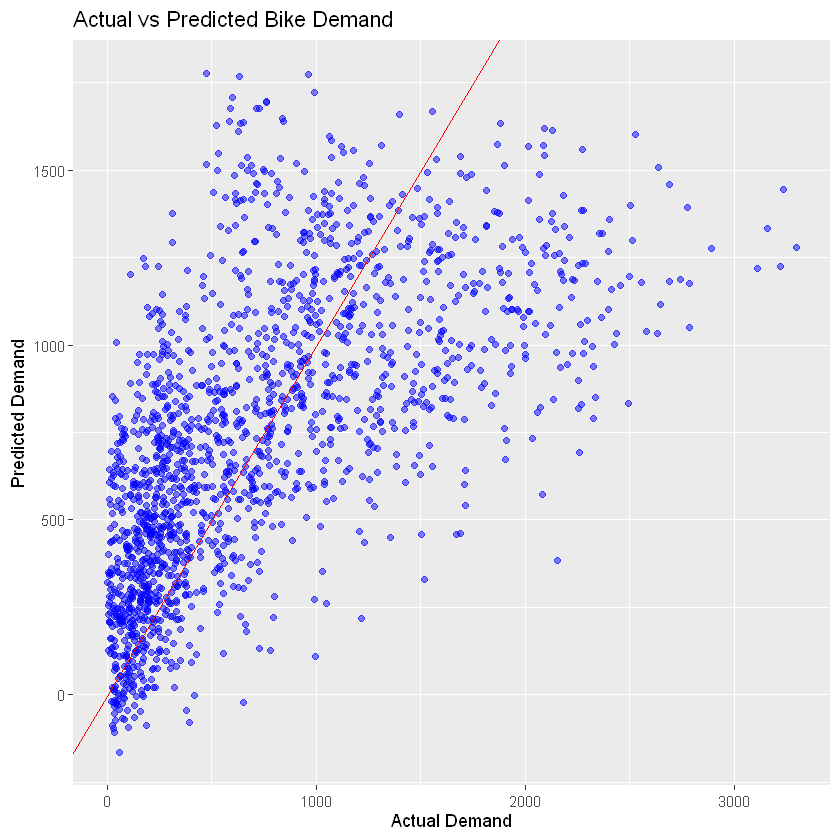

In [7]:
# Create comparison plot

ggplot(data = data.frame(
  actual = test_data$rented_bike_count,
  predicted = predictions
), aes(x = actual, y = predicted)) +
  geom_point(color = "blue", alpha = 0.5) +
  geom_abline(slope = 1, intercept = 0, color = "red") +
  labs(
    title = "Actual vs Predicted Bike Demand",
    x = "Actual Demand",
    y = "Predicted Demand"
  )

## Interpretation

From the baseline model:

- Weather variables explain a portion of bike demand variability
- The model provides a reasonable starting point
- However, it may not capture complex patterns such as:
  - Time-based variations
  - Non-linear relationships

This motivates further model refinement in the next stage.

---

## Author & Acknowledgment

**Author:**  
<span style="color:blue">Deepan Mehta </span>  

**GitHub Profile:**  
https://github.com/deepan-mehta-analytics

This notebook focuses on building and evaluating a baseline linear regression model using weather-related features.

The workflow follows <span style="color:blue">IBM Skills Network </span> instructional labs on regression modeling and baseline model development.

Special acknowledgment is given to:

- <span style="color:blue">Yan Luo </span>  
- <span style="color:blue">Jeff Grossman</span>  

---

## Project Context

This notebook represents the baseline modeling stage in the end-to-end data science pipeline:

- Data Collection  
- Data Wrangling (ETL)  
- Exploratory Data Analysis (EDA)  
- **Baseline Model Development**  
- Model Refinement  
- Model Evaluation  
- Deployment (R Shiny Dashboard)

---

## Notes

This baseline model serves as a reference point for evaluating improvements introduced in subsequent modeling stages.

---